In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_stata('../data/renamed_rows_final.dta')
numeric_df = df.select_dtypes(include=['number'])

In [3]:
df['year'].unique()

array([2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2005], dtype=int16)

In [4]:
df.columns

Index(['country_code', 'year', 'electricity_access', 'borrowers', 'cpi',
       'cpia_econ_rating', 'cpia_financial_rating', 'cpia_gender_eq_rating',
       'cpia_macro_rating', 'cpia_social_inclus_rating',
       'cpia_prpty_rights_rating', 'cpia_social_protctn_rating',
       'depth_of_credit', 'dmstc_crdt_financial', 'dmstc_crdt_privt',
       'export_volume', 'informal_payments', 'inflation', 'country_name',
       'gdp_deflator', 'gdp_constant', 'gdp_pc_growth', 'cpia_avg_rating'],
      dtype='object')

In [19]:
df.sort_values('inflation',ascending=False)[['country_name','year','inflation']]

,country_name,year,inflation
912,Zimbabwe,2007,24411.030810
911,Zimbabwe,2006,1096.677633
718,South Sudan,2016,380.776904
910,Zimbabwe,2005,302.116996
717,South Sudan,2015,50.150598
...,...,...,...
830,Uzbekistan,2016,NaN
896,"Yemen, Rep.",2015,NaN
897,"Yemen, Rep.",2016,NaN
913,Zimbabwe,2008,NaN


## Correlation Matrix

In [5]:
cov = numeric_df.cov()
corr = numeric_df.corr()

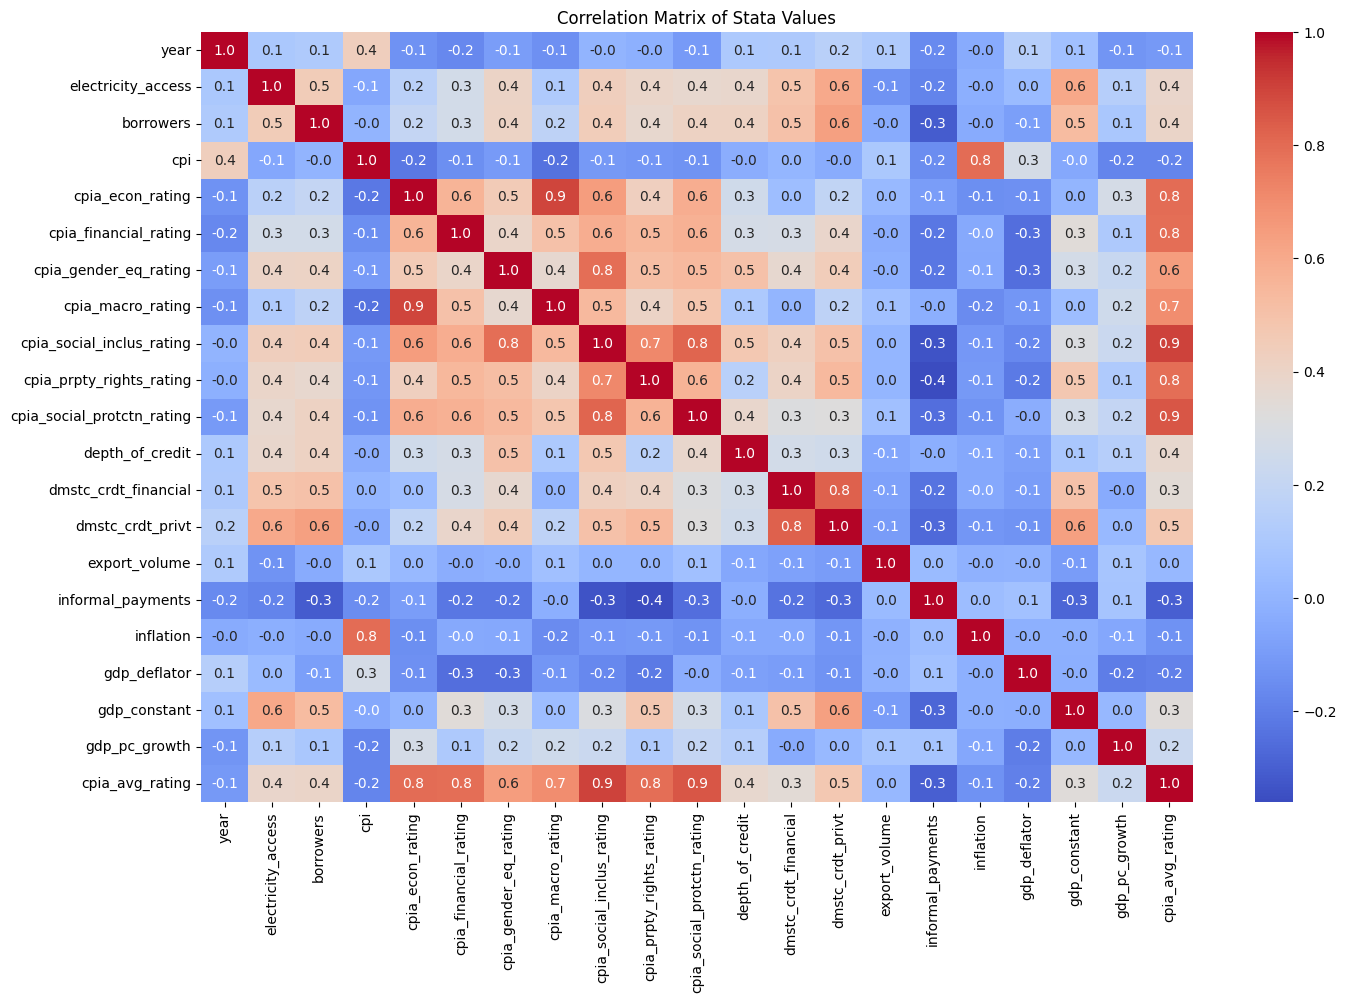

In [6]:
# Set up the figure
def heatmap(df,title,annot=True,figsize=(16,10)):
    plt.figure(figsize = (16, 10))
    g = sns.heatmap(df,annot=annot,cmap='coolwarm',fmt='.1f' if annot else '')
    plt.title(title)
    return g

def plot_corr_and_cov(df, corr_title, cov_title, figsize=(16, 10)):
    """
    Plots the correlation and covariance matrices side by side in a single figure.

    Parameters:
    - df: DataFrame containing the data.
    - corr_title: Title for the correlation matrix plot.
    - cov_title: Title for the covariance matrix plot.
    - figsize: Tuple specifying the figure size.
    - annot: Whether to annotate the heatmap with values.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)  # Create two subplots side by side

    # Correlation matrix
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
    axes[0].set_title(corr_title)

    # Covariance matrix
    cov = df.cov()
    sns.heatmap(cov, annot=False, cmap='coolwarm', fmt='.2f', ax=axes[1])
    axes[1].set_title(cov_title)

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

g = heatmap(corr,"Correlation Matrix of Stata Values")
plt.show()
#corr['cpi'].plot(kind='bar',figsize=(12,8),title='Consumer Price Index Results')

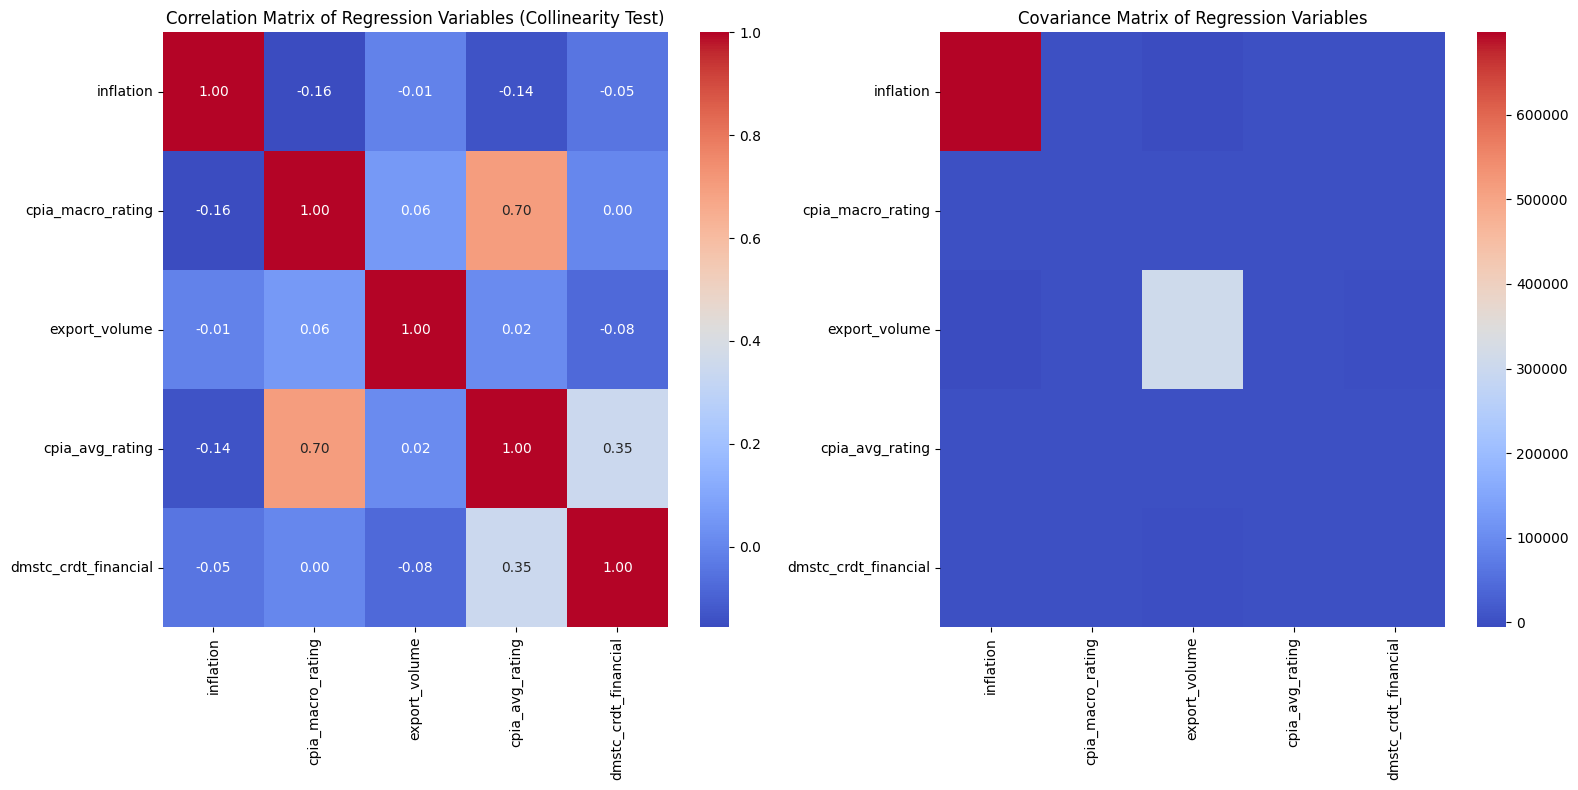

In [7]:
#Correlation Matrix of Final Values
df['cpia_macro_rating_export_volume'] = df['cpia_macro_rating'] * df['export_volume']
columns_needed = [
    'inflation', 
    'cpia_macro_rating', 
    'export_volume', 
    #'cpia_macro_rating_export_volume',  # <-- the interaction term
    'cpia_avg_rating', 
    'dmstc_crdt_financial'
]

final_regressed_model = df[columns_needed].rename(
    {
        'inflation':'Inflation (%)',
        'cpia_macro_rating':'CPIA Macroeconomic Rating',
        'export_volume':'Export Volume',
        'cpia_avg_rating':"CPIA Average Rating",
        'dmst_cdt_financial':"Domestic Financial Credit"
    }
)


plot_corr_and_cov(final_regressed_model,
                  "Correlation Matrix of Regression Variables (Collinearity Test)",
                  "Covariance Matrix of Regression Variables",
                  (16,8))

## Primary Variable Graphs

In [9]:
#'CPIAmacroeconomicmanagementra' 
#'Consumerpriceindex2010100'
renamed = df.rename({
    'cpia_macro_rating':'EconManagement'
    },
    axis=1)
filtered = renamed[renamed['EconManagement'] >= 2]

In [10]:
FONT_SIZE = 11
Y_AX_NAME = '% Change in Inflation'

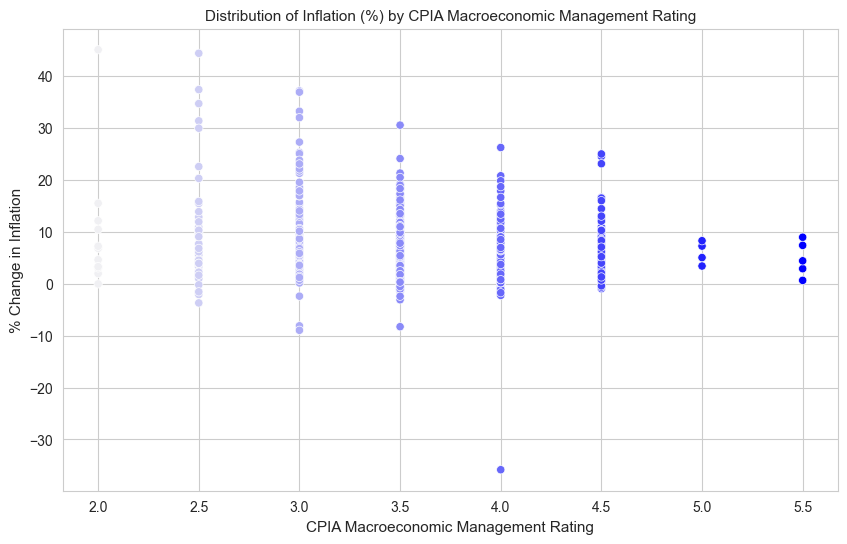

In [11]:
plt.figure(figsize=(10,6))
sns.set_palette('light:b')
sns.set_style("whitegrid")
sns.scatterplot(filtered,x='EconManagement',y='inflation',hue='EconManagement',legend=False,palette='light:b')
plt.title("Distribution of Inflation (%) by CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.xlabel("CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.ylabel(Y_AX_NAME, fontsize=FONT_SIZE)
plt.show()

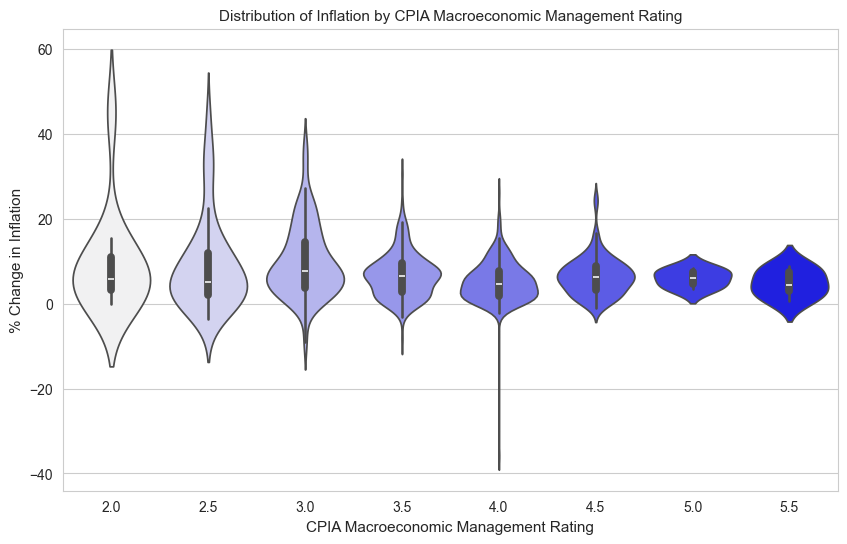

In [12]:
plt.figure(figsize=(10,6))
sns.set_palette('light:b')
sns.set_style("whitegrid")
sns.violinplot(filtered,x='EconManagement',y='inflation',hue='EconManagement',legend=False,palette='light:b')
plt.title("Distribution of Inflation by CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.xlabel("CPIA Macroeconomic Management Rating",fontsize=FONT_SIZE)
plt.ylabel(Y_AX_NAME, fontsize=FONT_SIZE)
plt.show()

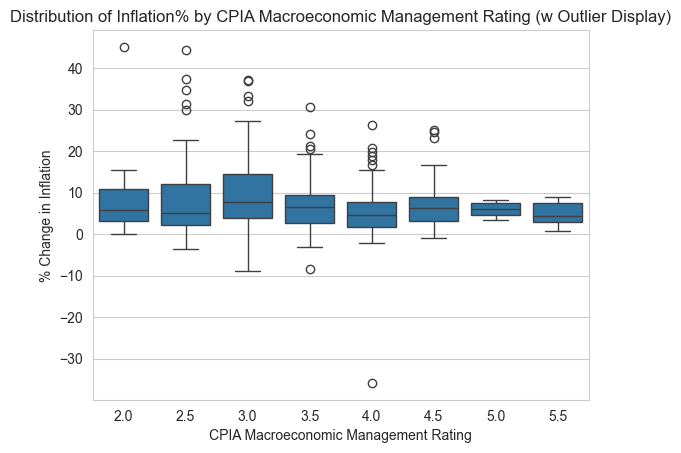

In [13]:
sns.set_palette('tab10')
sns.set_style('whitegrid')
sns.boxplot(filtered,x='EconManagement',y='inflation')


plt.title("Distribution of Inflation% by CPIA Macroeconomic Management Rating (w Outlier Display)")
plt.xlabel("CPIA Macroeconomic Management Rating")
plt.ylabel(Y_AX_NAME)
plt.show()

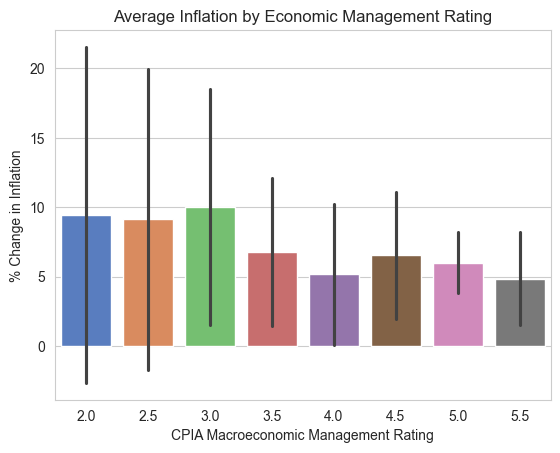

In [14]:
sns.barplot(data=filtered, 
            x='EconManagement', 
            y='inflation',
            errorbar='sd', 
            hue='EconManagement',
            palette='muted',
            legend=False)
plt.title("Average Inflation by Economic Management Rating")
plt.xlabel("CPIA Macroeconomic Management Rating")
plt.ylabel(Y_AX_NAME)
plt.show()

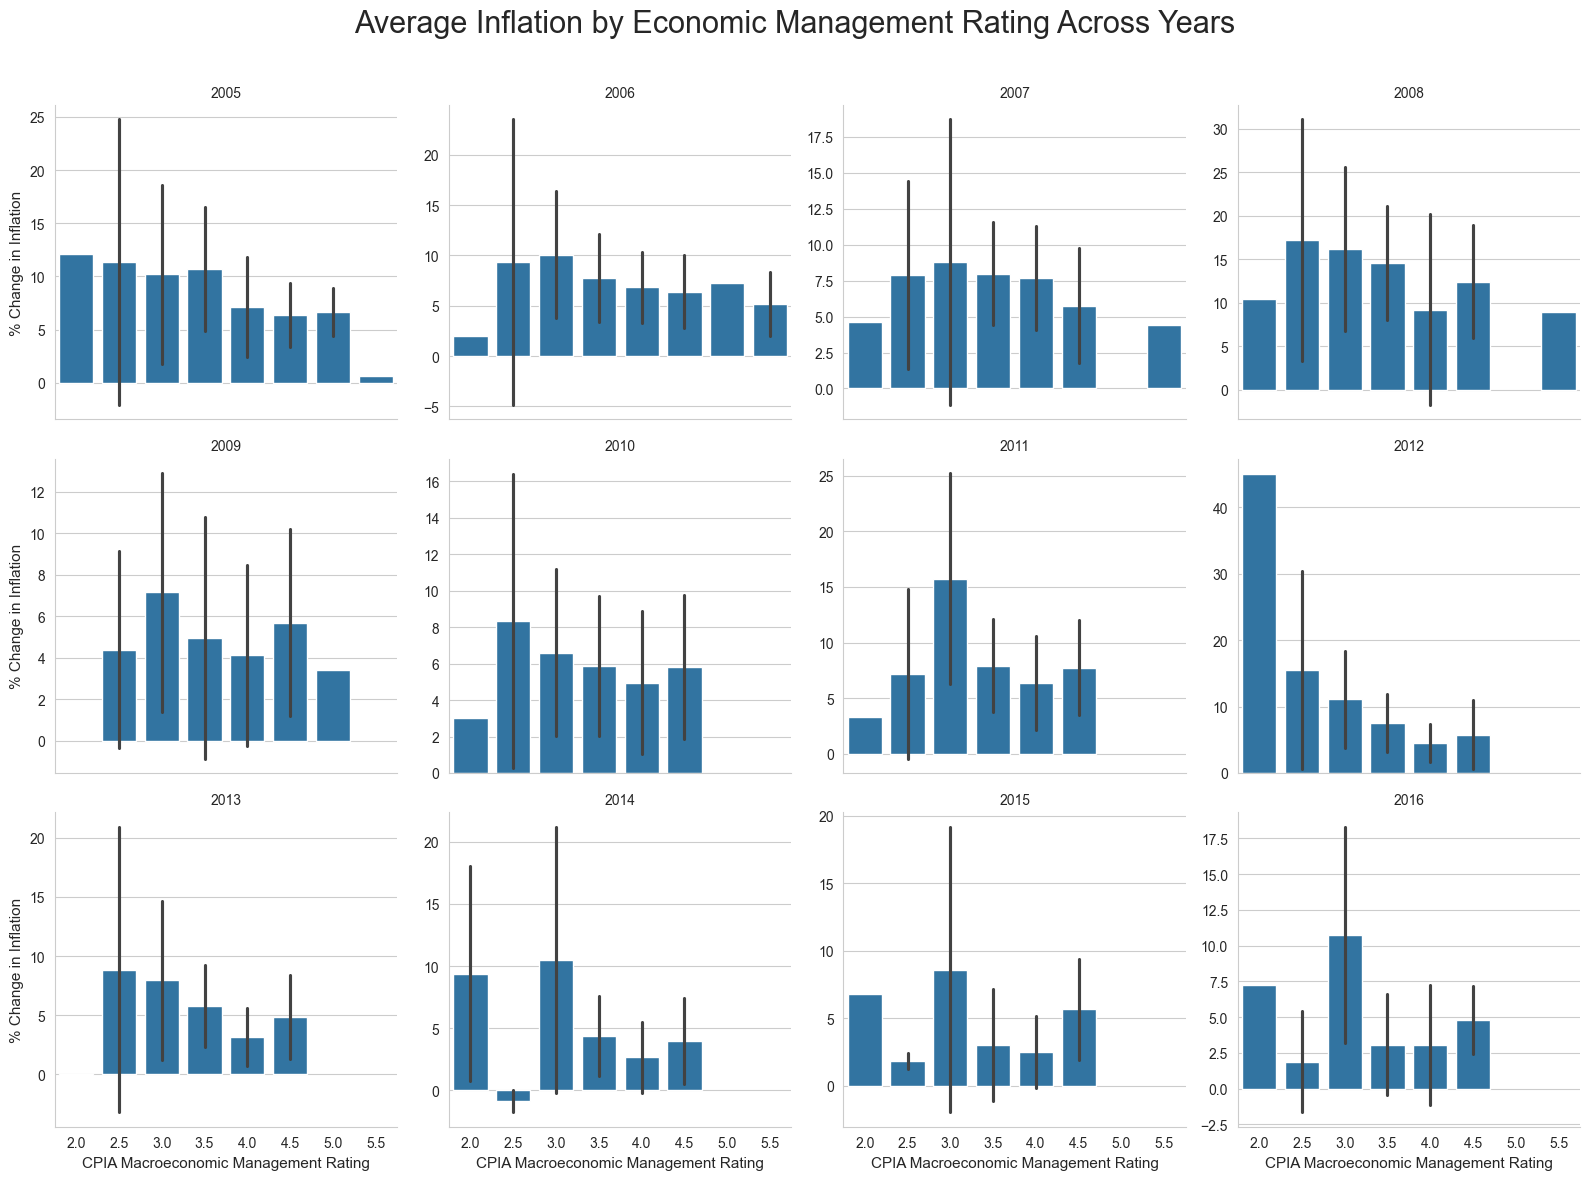

In [15]:
def facet_grid(filtered, filter_col, filter_col_name):
      g = sns.FacetGrid(filtered, col=filter_col, col_wrap=4, height=4, sharey=False)
      g.map(sns.barplot, 
            "EconManagement", 
            "inflation", 
            order=sorted(filtered['EconManagement'].unique())[:16],
            errorbar="sd")
      
      g.set_titles("{col_name}")
      g.set_axis_labels("CPIA Macroeconomic Management Rating", Y_AX_NAME,fontsize=FONT_SIZE)
      plt.subplots_adjust(top=0.9)
      g.figure.suptitle(f"Average Inflation by Economic Management Rating Across {filter_col_name}s",fontsize=FONT_SIZE*2)
      plt.show()

facet_grid(filtered,'year','Year')